# S2 Coursework DRAFT

## Question 1: Accident data

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

from varateMC import change_point as cp_utils
from varateMC import constant_rate as cr_utils
from varateMC import data as data_utils
from varateMC import priors as priors_utils
from varateMC import rjmcmc as rj_utils

In [ ]:
dataset = data_utils.load_mining_data()
flattened_data_cumulative = dataset["flattened_data_cumulative"]

total_period = 40550
total_events = 191

number_of_accidents = dataset["number_of_accidents"]

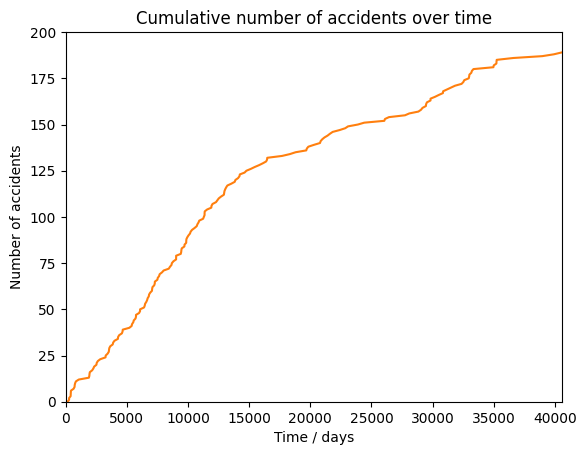

In [ ]:
plt.plot(flattened_data_cumulative, number_of_accidents, color="tab:orange")
plt.xlabel("Time / days")
plt.ylabel("Number of accidents")
plt.title("Cumulative number of accidents over time")
plt.xlim(0,40550)
plt.ylim(0,200)
plt.savefig(os.path.join('figs','cumulative_accidents_over_time.png'), dpi=300)
plt.show()

In [ ]:
mean_rate, mean_rate_year = data_utils.mean_rates(
    total_events=total_events,
    total_period=total_period,
    number_of_accidents=number_of_accidents,
 )
print(f"Mean rate of accidents: {mean_rate:.4f} per day")
print(f"Mean rate of accidents: {mean_rate_year:.2f} per year")

Mean rate of accidents: 0.0047 per day
Mean rate of accidents: 1.70 per year


## Question 2: Priors

### (a)

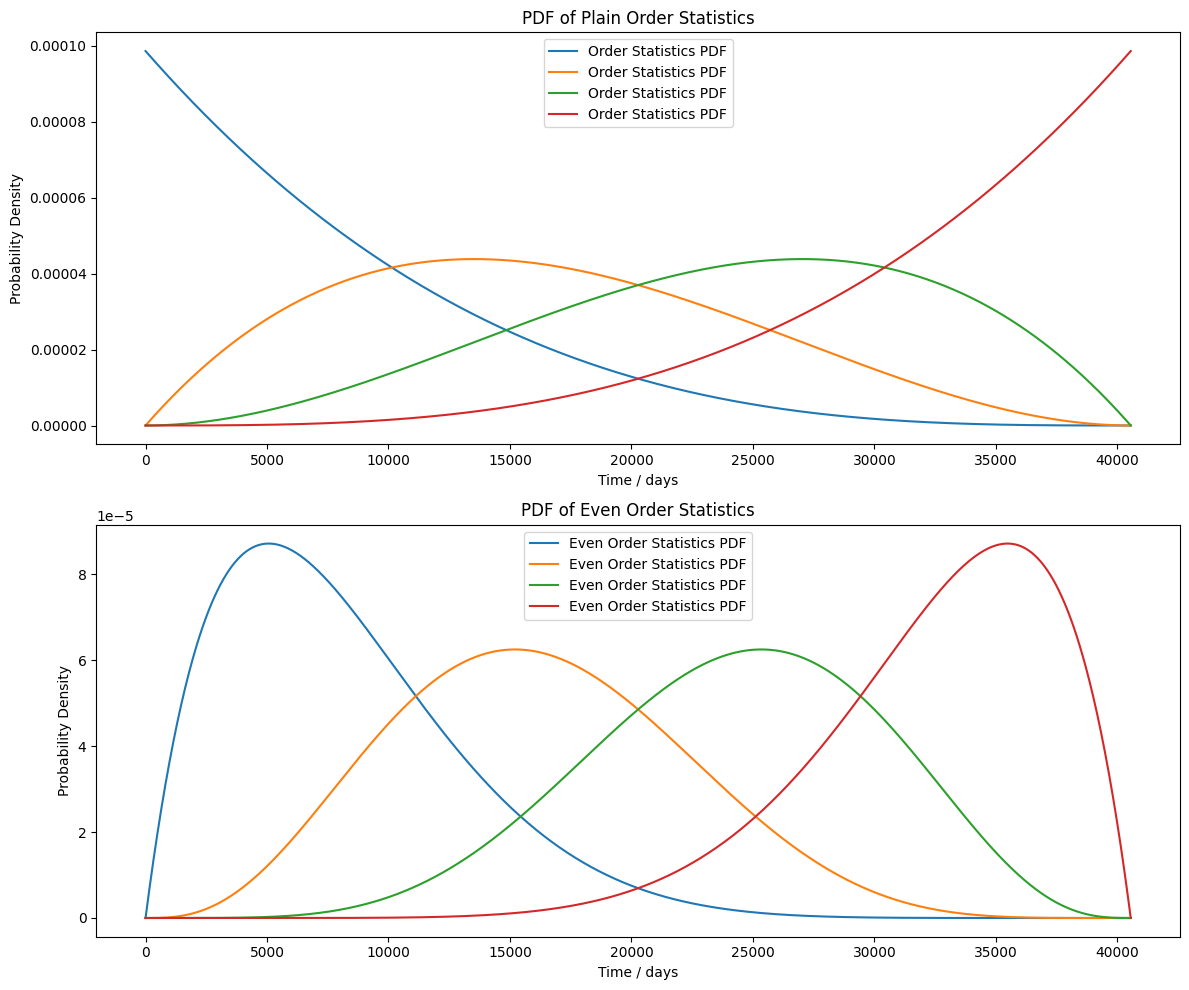

In [ ]:
import math

# Plot the distributions of the order statistics and even order statistics
x = np.linspace(0, total_period, 1000)

plain_pdfs, even_pdfs = priors_utils.order_statistics_pdfs(x, total_period)

pdf_plain_order_statistics_1 = plain_pdfs["u1"]
pdf_plain_order_statistics_2 = plain_pdfs["u2"]
pdf_plain_order_statistics_3 = plain_pdfs["u3"]
pdf_plain_order_statistics_4 = plain_pdfs["u4"]

pdf_even_order_statistics_1 = even_pdfs["v1"]
pdf_even_order_statistics_2 = even_pdfs["v2"]
pdf_even_order_statistics_3 = even_pdfs["v3"]
pdf_even_order_statistics_4 = even_pdfs["v4"]

fig, axs = plt.subplots(2, 1, figsize=(12, 10))
axs[0].plot(x, pdf_plain_order_statistics_1, label='Order Statistics PDF')
axs[0].plot(x, pdf_plain_order_statistics_2, label='Order Statistics PDF')
axs[0].plot(x, pdf_plain_order_statistics_3, label='Order Statistics PDF')
axs[0].plot(x, pdf_plain_order_statistics_4, label='Order Statistics PDF')
axs[0].set_title('PDF of Plain Order Statistics')
axs[0].set_xlabel("Time / days")
axs[0].set_ylabel("Probability Density")
axs[0].legend()
axs[1].plot(x, pdf_even_order_statistics_1, label='Even Order Statistics PDF')
axs[1].plot(x, pdf_even_order_statistics_2, label='Even Order Statistics PDF')
axs[1].plot(x, pdf_even_order_statistics_3, label='Even Order Statistics PDF')
axs[1].plot(x, pdf_even_order_statistics_4, label='Even Order Statistics PDF')
axs[1].set_title('PDF of Even Order Statistics')
axs[1].set_xlabel("Time / days")
axs[1].set_ylabel("Probability Density")
axs[1].legend()
plt.tight_layout()
plt.savefig(os.path.join('figs','order_statistics_pdfs.png'), dpi=300)
plt.show()

## Question 3: The constant rate model

### (a)

The prior on $h_0$ is 

\begin{equation}
    \pi(h_0|M_0)=\beta^\alpha\exp(-\beta h)/\Gamma(\alpha),
\end{equation}

where $\alpha=1$, $\beta=200\;\text{days}$. In the constant rate case, the log-likelihood is simply

\begin{equation}
    \log\mathcal{L}(\{I_i\}|h_0,M_0)=N\log h_0-h_0L.
\end{equation}

The posterior on $h_0$ is thus

\begin{equation}
    P(h_0|\{I_i\}, M_0)=200h_0^N\exp(-h_0(200+L)).
\end{equation}

In [ ]:
alpha = 1
beta = 200

/tmp/ipykernel_15380/678437914.py:14: RuntimeWarning: divide by zero encountered in log
  return total_events * np.log(h) - h * total_period


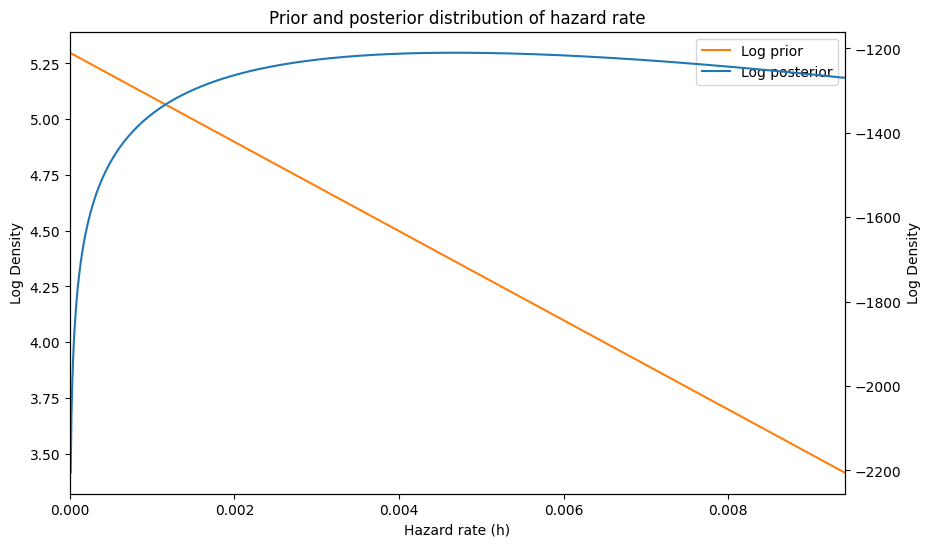

Constant for numerical stability: -1210.0228


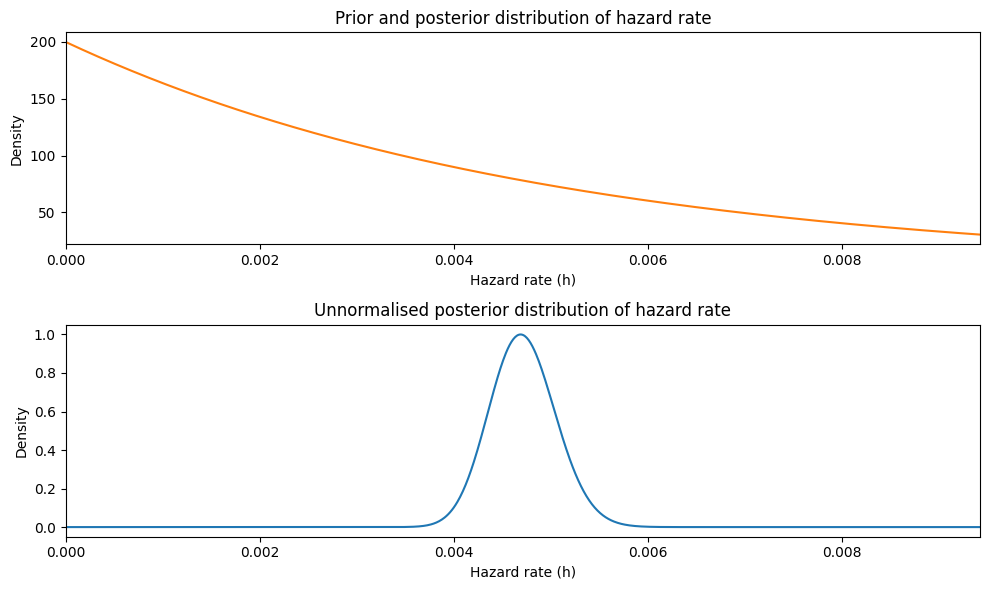

In [ ]:
h_values, log_prior_values, log_posterior_values = cr_utils.evaluate_constant_rate_grid(
    total_events=total_events,
    total_period=total_period,
    alpha=alpha,
    beta=beta,
    n=1000,
 )

fig, ax = plt.subplots(figsize=(10, 6))
ax2 = ax.twinx()
p1 = ax.plot(h_values, log_prior_values, color="tab:orange", label="Log prior")
p2 = ax2.plot(h_values, log_posterior_values, color="tab:blue", label="Log posterior")

ax.set_xlabel("Hazard rate (h)")
ax.set_ylabel("Log Density")
ax.set_title("Prior and posterior distribution of hazard rate")
ax.set_xlim(0, 191 * 2 / 40550)
ax2.set_ylabel("Log Density")

ps = p1 + p2
labels = [p.get_label() for p in ps]
ax.legend(ps, labels, loc=0)

plt.show()

constant = np.max(log_posterior_values)
print(f"Constant for numerical stability: {constant:.4f}")

fig, ax = plt.subplots(2, 1, figsize=(10, 6))
ax[0].plot(h_values, np.exp(log_prior_values), color="tab:orange", label="Prior")
ax[1].plot(h_values, np.exp(log_posterior_values - constant), color="tab:blue", label="Posterior")
ax[0].set_xlabel("Hazard rate (h)")
ax[0].set_ylabel("Density")
ax[0].set_title("Prior and posterior distribution of hazard rate")
ax[0].set_xlim(0, 191 * 2 / 40550)
ax[1].set_xlabel("Hazard rate (h)")
ax[1].set_ylabel("Density")
ax[1].set_title("Unnormalised posterior distribution of hazard rate")
ax[1].set_xlim(0, 191 * 2 / 40550)
plt.tight_layout()
plt.savefig(os.path.join('figs','hazard_rate_prior_posterior.png'), dpi=300)
plt.show()

Computing the evidence from the unnormalised posterior requires scaling the integrand by a constant to avoid underflow errors. The evidence is given by

\begin{equation}
    Z=\int_0^\infty 200h_0^N\exp(-h_0(200+L))dh_0.
\end{equation}

We can compute the maximum of the log-integrand, which turns out to be at $h_0=\frac{N}{200+L}$. Subtracting the log-integrand evaluated at this point we get

\begin{equation}
    \log\tilde{P}=\log P+\text{const}=N(\log\frac{h_0(200+L)}{N}+1)-h_0(200+L),
\end{equation}

where $\text{const}=\log(200(\frac{N}{200+L})^N)\exp(-N)$. With this, the evidence is given by

\begin{equation}
    Z=\exp(-\text{const})\int\exp\tilde{P}dh_0.
\end{equation}

In [ ]:
scaled_evidence, _ = cr_utils.compute_scaled_evidence(total_events, total_period, 0, 1)
print(f"Scaled evidence: {scaled_evidence:.10e}")

Scaled evidence: 8.5048858166e-04


The prefactor in the evidence $\exp(\text{const})$ is tiny. With the given parameters, it evaluates to

\begin{equation}
    200\biggl(\frac{191}{40750}\biggr)^{191}\exp(-191) = 3.12\times10^{-526}.
\end{equation}

As a result, the total evidence is

\begin{equation}
    Z=2.65\times10^{-529},
\end{equation}

\begin{equation}
    \log Z=-1217.09.
\end{equation}

## Question 4: The 1 change point model

### (a)

I have used the package `emcee` which implements an affine-invariant Markov Chain Monte Carlo ensemble sampler. Hamiltonian Monte Carlo and the No-U-Turn Sampler require continuous and differentiable likelihoods for computing gradients. Since this likelihood is discontinuous and not differentiable at one point, and later will be so at $k$ points, these algorithms will be inappropriate to use.

I initialise 50 walkers for each parameter which is significantly higher than the minimum recommendation for this problem ($2\times n_\text{dim}$) while still computing in under 20 seconds. I also use 20,000 steps for the algorithm to ensure that there are at least 50 independent samples per walker once thinned. This will yield tight constraints on parameter values since the Monte Carlo error scales as $1/\sqrt{N}$. I also conservatively discard the first 20% of each chain to remove burn-in as the chains find the bulk of the posterior.

To assess convergence, I compute the integrated autocorrelation timescale which is the standard measure used in such problems. It gives an estimate of the number of samples in a chain between independent samples. I then use this value to thin the chains for later inference. For this problem, the Gelman-Rubin ratio is an inappropriate measure of convergence since it assumes that each chain is independent of one another, which is not true for ensemble MCMC algorithms. This would lead to false positives for convergence, which is undesirable as it would suggest that sampling should be terminated prematurely. I also check that the mean acceptance fraction is in a sensible range (10-50%) and visually inspect the trace plots once burn-in is removed. I measure an acceptance fraction at the top of this range, which is appropriate for a low-dimensional problem and indicates that the chains are making large enough steps to explore the high posterior density regions efficiently, while the trace plots exhibit the expected behaviour.

In [ ]:
alpha_param = 1
beta_param = 200

mcmc_results = cp_utils.run_one_change_emcee(
    event_times=flattened_data_cumulative,
    total_period=total_period,
    nwalkers=100,
    nsteps=10000,
    alpha=alpha_param,
    beta_param=beta_param,
    burnin_fraction=0.2,
 )

sampler = mcmc_results["sampler"]
samples = mcmc_results["samples"]
autocorrtime = mcmc_results["autocorrtime"]
thinning_factor = mcmc_results["thinning_factor"]
acceptance_fraction = mcmc_results["acceptance_fraction"]
nburnin = mcmc_results["nburnin"]
ndim = mcmc_results["ndim"]

print(f"Autocorrelation time for sampler: {autocorrtime}")
print(f"Mean acceptance fraction: {np.mean(acceptance_fraction):.4f}")

  0%|          | 0/10000 [00:00<?, ?it/s]/tmp/ipykernel_15380/2732348060.py:16: RuntimeWarning: invalid value encountered in log
  log_likelihood_value = n_0 * np.log(h_0) - h_0 * T_0 + n_1 * np.log(h_1) - h_1 * T_1
100%|██████████| 10000/10000 [00:12<00:00, 788.36it/s]


Autocorrelation time for sampler: [47.06806936 45.42515881 47.16602049]
Mean acceptance fraction: 0.5258


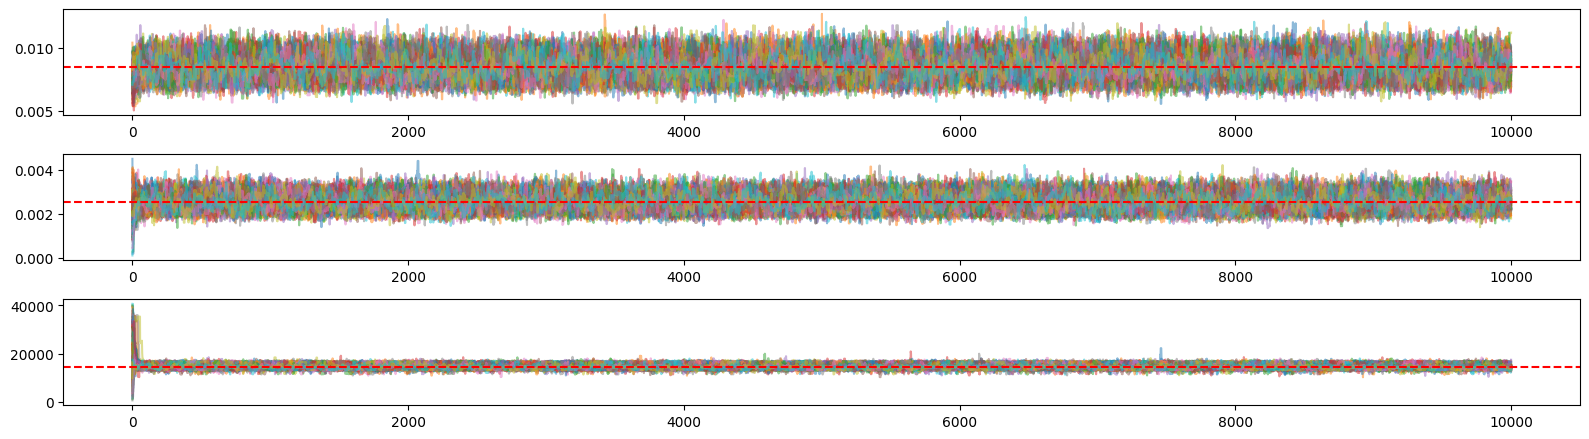

In [ ]:
# Plot unthinned chains with burn in
plt.figure(figsize=(16,1.5*ndim))
for n in range(ndim):
    plt.subplot2grid((ndim, 1), (n, 0))
    plt.plot(sampler.get_chain()[:,:,n],alpha=0.5)
    plt.axhline(y=np.mean(samples[:, n]), color='red', linestyle='--')
plt.tight_layout()
plt.show()

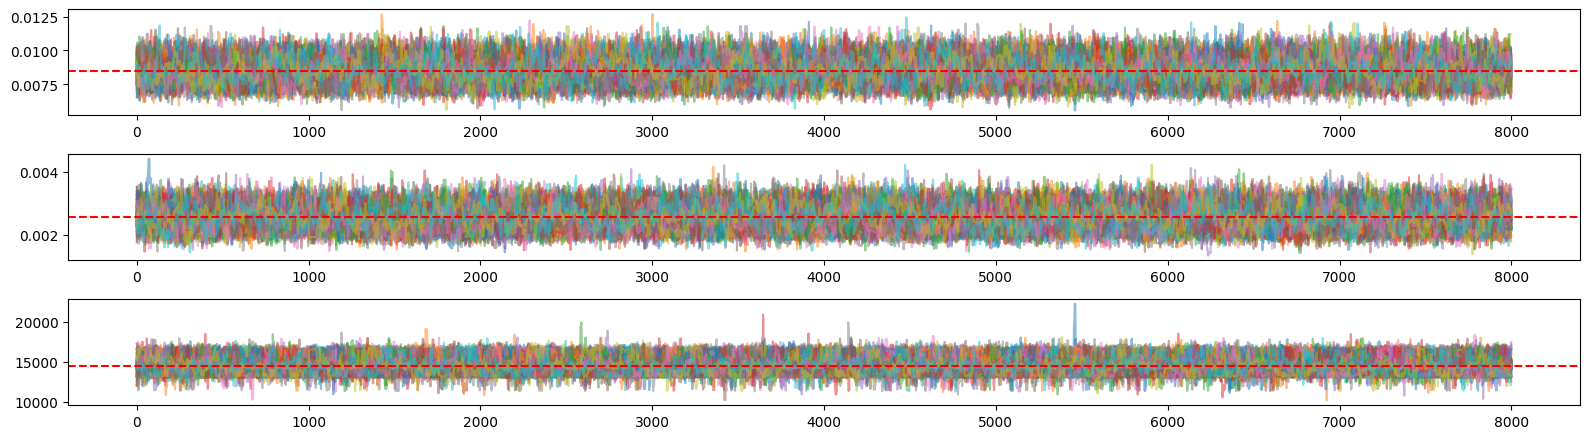

In [ ]:
# Plot with burn in removed
plt.figure(figsize=(16,1.5*ndim))
for n in range(ndim):
    plt.subplot2grid((ndim, 1), (n, 0))
    plt.plot(sampler.get_chain(discard=nburnin)[:,:,n],alpha=0.5)
    plt.axhline(y=np.mean(samples[:, n]), color='red', linestyle='--')
plt.tight_layout()
plt.savefig(os.path.join('figs','mcmc_chains_no_burnin.png'), dpi=300)
plt.show()

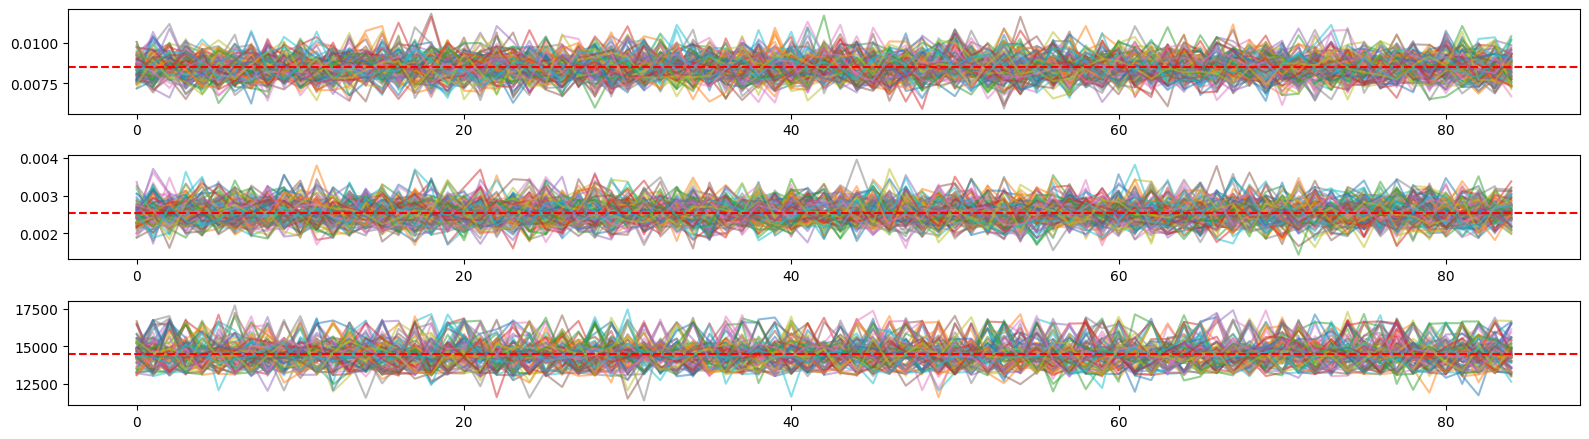

In [ ]:
# Plot with burn in removed and chains thinned
plt.figure(figsize=(16,1.5*ndim))
for n in range(ndim):
    plt.subplot2grid((ndim, 1), (n, 0))
    plt.plot(sampler.get_chain(discard=nburnin, thin=thinning_factor)[:,:,n],alpha=0.5)
    plt.axhline(y=np.mean(samples[:, n]), color='red', linestyle='--')
plt.tight_layout()
plt.savefig(os.path.join('figs','mcmc_chains_no_burnin_thinned.png'), dpi=300)
plt.show()

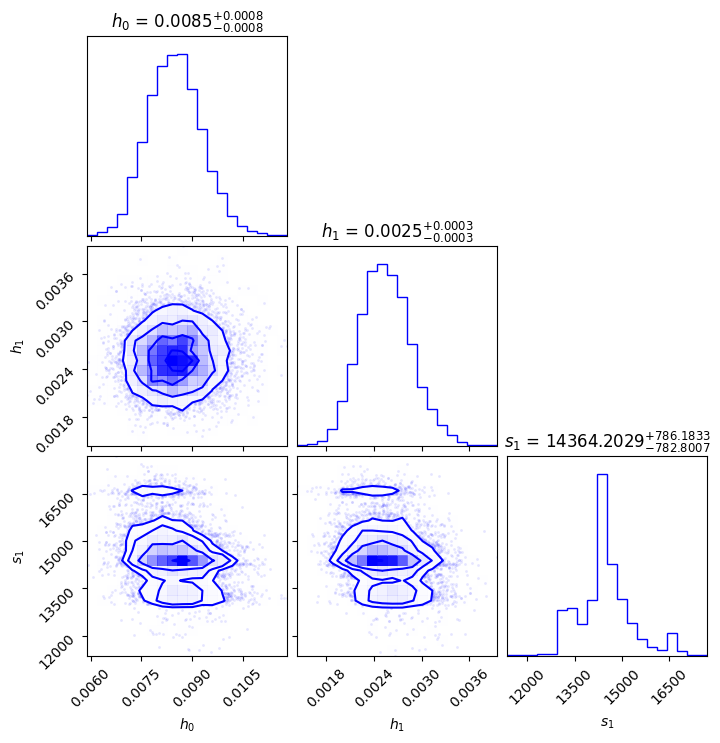

In [ ]:
import corner
labels = ["$h_0$", "$h_1$", "$s_1$"]
fig = corner.corner(samples.reshape(-1, ndim), color="blue", labels=labels, show_titles=True, title_fmt=".4f", title_kwargs={"fontsize": 12})
plt.savefig(os.path.join('figs','k_1_corner_plot.png'), dpi=300)
plt.show()

MAP estimate of h_0: 0.0085
MAP estimate of h_1: 0.0026
MAP estimate of s_1: 14463.48 days


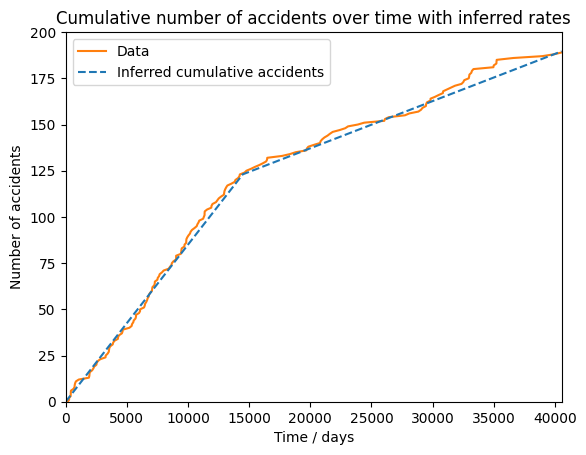

In [ ]:
# Make a plot of cumulative number of accidents over time.
# Overlay the plot with the rate inferred from the MCMC samples, showing the change point and the two 
# different rates before and after the change point.
h_0_map = np.mean(samples[:, 0])
h_1_map = np.mean(samples[:, 1])
s_1_map = np.mean(samples[:, 2])
print(f"MAP estimate of h_0: {h_0_map:.4f}")
print(f"MAP estimate of h_1: {h_1_map:.4f}")
print(f"MAP estimate of s_1: {s_1_map:.2f} days")

time = np.linspace(0, total_period, total_period)
inferred_rate = np.where(time < s_1_map, h_0_map, h_1_map)
inferred_cumulative = np.cumsum(inferred_rate)


plt.plot(flattened_data_cumulative, number_of_accidents, color="tab:orange", label="Data")
plt.plot(time, inferred_cumulative, color="tab:blue", label="Inferred cumulative accidents", linestyle="dashed")
plt.xlabel("Time / days")
plt.ylabel("Number of accidents")
plt.title("Cumulative number of accidents over time with inferred rates")
plt.xlim(0,40550)
plt.ylim(0,200)
plt.legend()
#plt.savefig(os.path.join('figs','cumulative_accidents_with_inferred_rates.png'))
plt.show()

### (b)

Consider two models $M_0$ and $M_1$ with parameters $\phi$ and $(\epsilon,\phi)$ respectively. We say that $M_0$ is nested within $M_1$ if for some fixed value of $\epsilon$, say $\epsilon_0$, the two models have the same likelihood function:

\begin{equation*}
    \mathcal{L}(d|\phi,M_0)=\mathcal{L}(d|\epsilon=\epsilon_0,\phi,M_1).
\end{equation*}

To use the Savage-Dickey ratio, we require that the two models also have consistent priors i.e.

\begin{equation*}
    \pi(\phi|M_0)=\pi(\phi|\epsilon=\epsilon_0,M_1).
\end{equation*}

The prior for the simpler model can be expressed as

\begin{equation*}
    Z_{M_0}=P(d|M_0)=\int d\phi\mathcal{L}(d|\phi,M_0)\pi(\phi|M_0)\\
    =\int d\phi\mathcal{L}(d|\epsilon=\epsilon_0,\phi,M_1)\pi(\phi|\epsilon=\epsilon_0,M_1)=P(d|\epsilon=\epsilon_0, M_1)
\end{equation*}

\begin{equation*}
    Z_{M_0}=\frac{P(\epsilon=\epsilon_0|d,M_1)}{P(\epsilon=\epsilon_0|M_1)}P(d|M_1).
\end{equation*}

We can then write the Bayes factor, defined as the ratio of the evidences under each model, as the ratio of a 1-dimensional posterior PDF to the 1-dimension prior PDF both evaluated at $\epsilon=\epsilon_0$:

\begin{equation*}
    \mathcal{B}_{01}=\frac{P(\epsilon=\epsilon_0|d,M_1)}{P(\epsilon=\epsilon_0|M_1)}.
\end{equation*}

The prior in the denominator is usually an analytic function, so is easy to evaluate, while the posterior is more difficult. Typically, you would use an MCMC algorithm, discarding values of any irrelevant parameters to estimate the posterior on $\epsilon$ which can then be evaluated through a kernel density estimate (KDE), for example. When computing the KDE, values of $\epsilon=\epsilon_0$ on the boundary of the prior can bias the density estimate. The model $M_0$ is recovered by setting $k=0$, which is on the boundary of the prior and may bias the KDE.

### (c)

The Laplace approximation in the multivariate case approximates the logarithm of the posterior PDF $\log P(\vec{x})$ using a Taylor expansion about its maximal point $\hat{\vec{x}}$. Here, all first derivates with respect to the model parameters $\vec{x}$ vanish, leaving

\begin{equation}
    \log P(\vec{x}) = \log P(\hat{\vec{x}}) - \frac{C_{ij}}{2}(\vec{x}_i-\hat{\vec{x}}_i)(\vec{x}_j-\hat{\vec{x}}_j)+...,
\end{equation}

where $C_{ij}=-\frac{\partial^2}{\partial x_i\partial x_j}\biggl|_{\vec{x}=\hat{\vec{x}}}\log P(\vec{x})$ is the Hessian of the log-posterior. The approximate posterior PDF is then a multivariate Gaussian distribution

\begin{equation}
    P(\vec{x})\approx P(\hat{\vec{x}})\exp(-\frac{C_{ij}}{2}(\vec{x}-\hat{\vec{x}})).
\end{equation}

The evidence is then easily computed using properties of the multivariate Gaussian distribution given by

\begin{equation}
    Z\approx P(\hat{\vec{x}})\sqrt{\frac{(2\pi)^D}{\text{det}(\mathbf{C})}}.
\end{equation}

The Laplace approximation relies on the posterior PDF being continuous and differentiable everywhere to compute the Hessian matrix. The posterior PDF changes discontinuously at the change points, so the assumption breaks down and the Laplace approximation cannot be used for this problem.

### (d)

Here I use `dynesty` to perform nested sampling, which takes as input the log-likelihood and a function that defines a transformation from the 

In [ ]:
sampler, results = cp_utils.run_one_change_nested(
    event_times=flattened_data_cumulative,
    total_period=total_period,
    ndim=3,
    nlive=1000,
    sample="unif",
    bound="multi",
    beta_param=beta_param,
 )

In [ ]:
results.summary()

8926it [00:17, 497.10it/s, +1000 | bound: 23 | nc: 1 | ncall: 59966 | eff(%): 16.833 | loglstar:   -inf < -1173.433 <    inf | logz: -1182.549 +/-  0.114 | dlogz:  0.001 >  1.009]


Summary
nlive: 1000
niter: 8926
ncall: 58966
eff(%): 16.833
logz: -1182.549 +/-  0.215


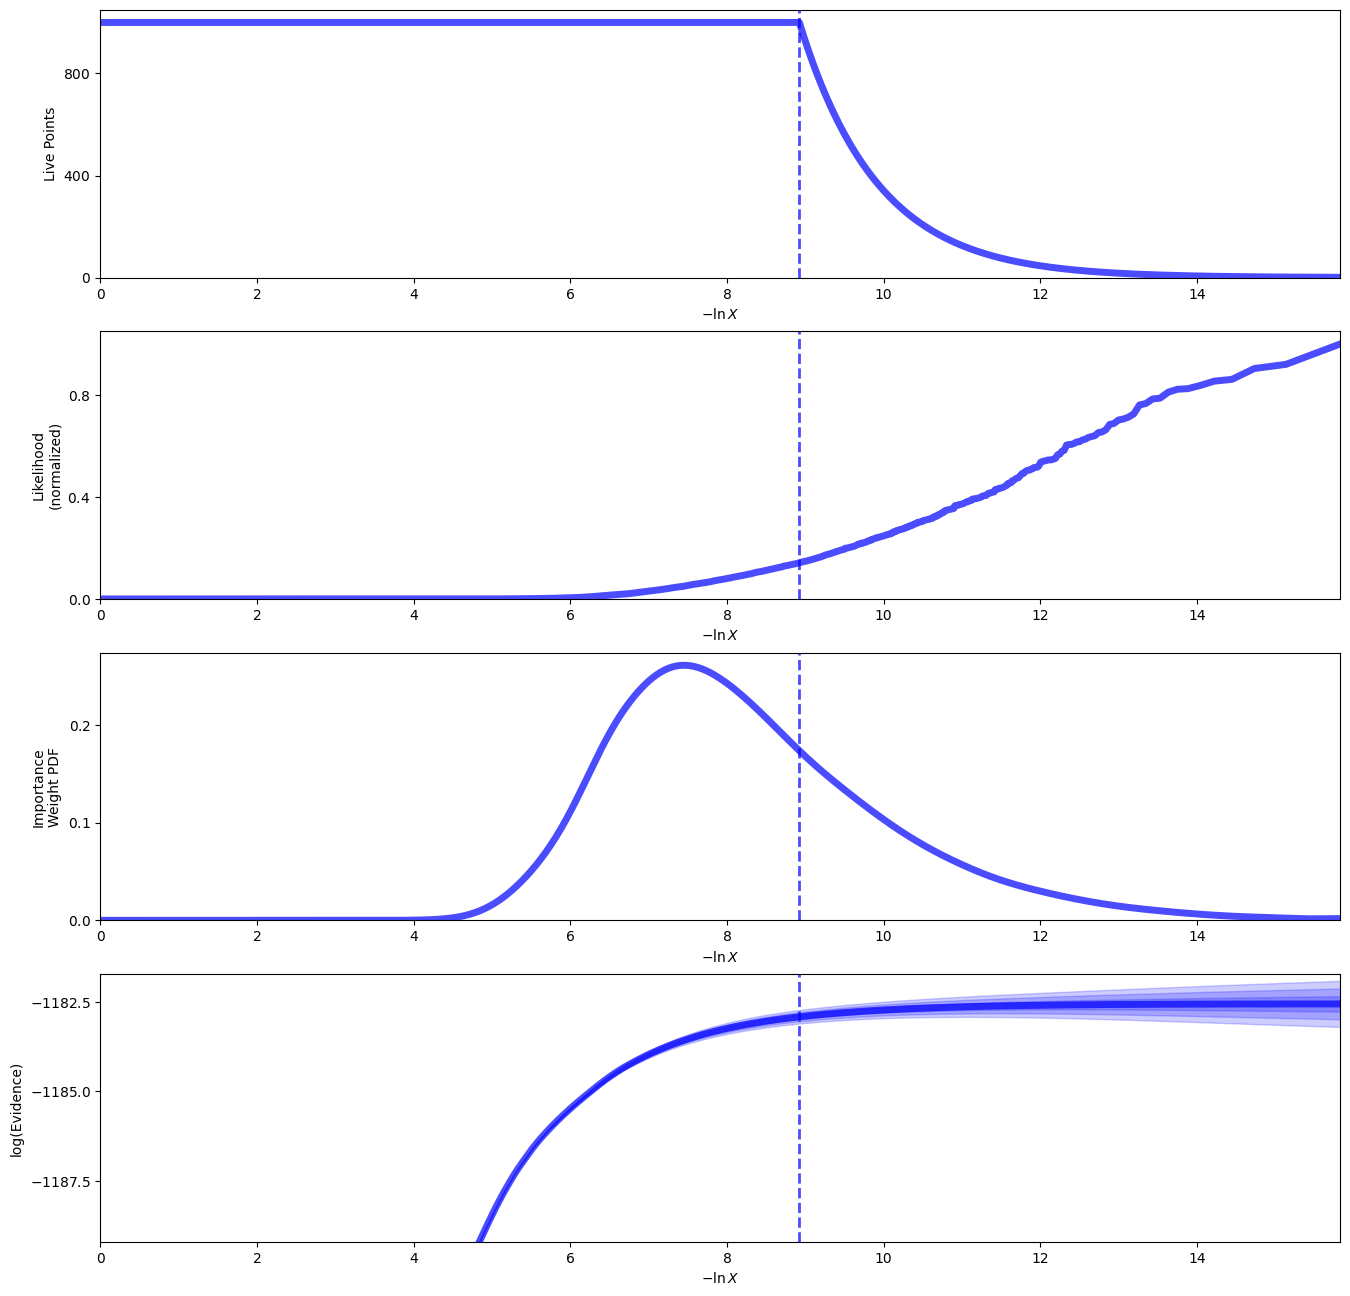

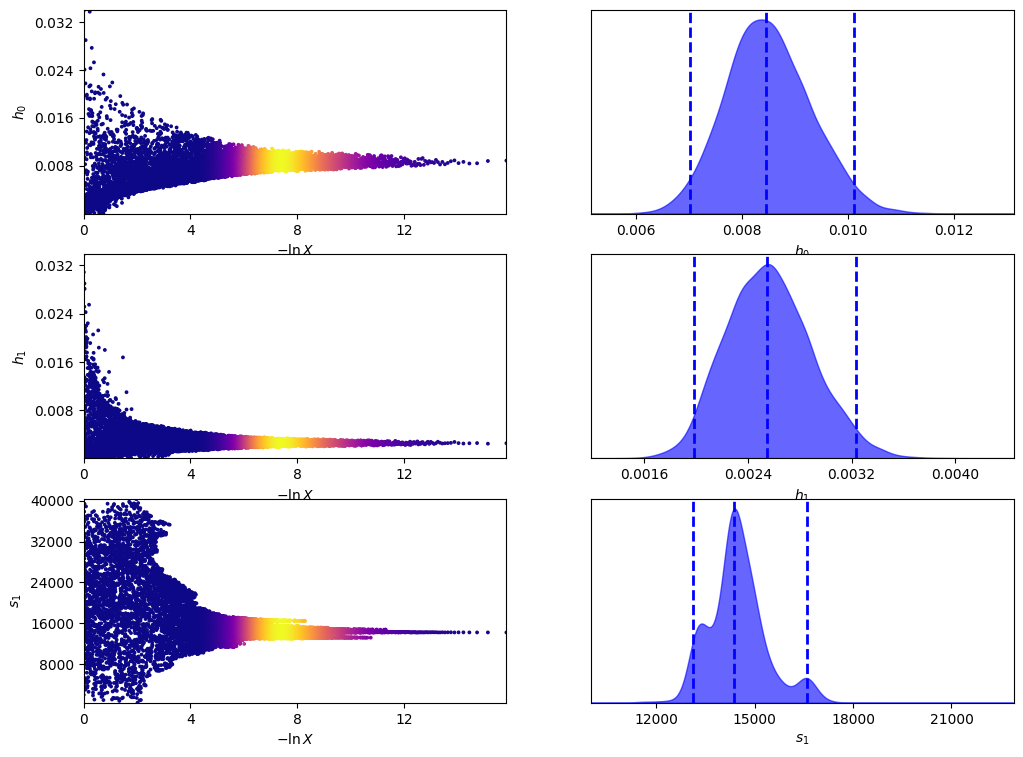

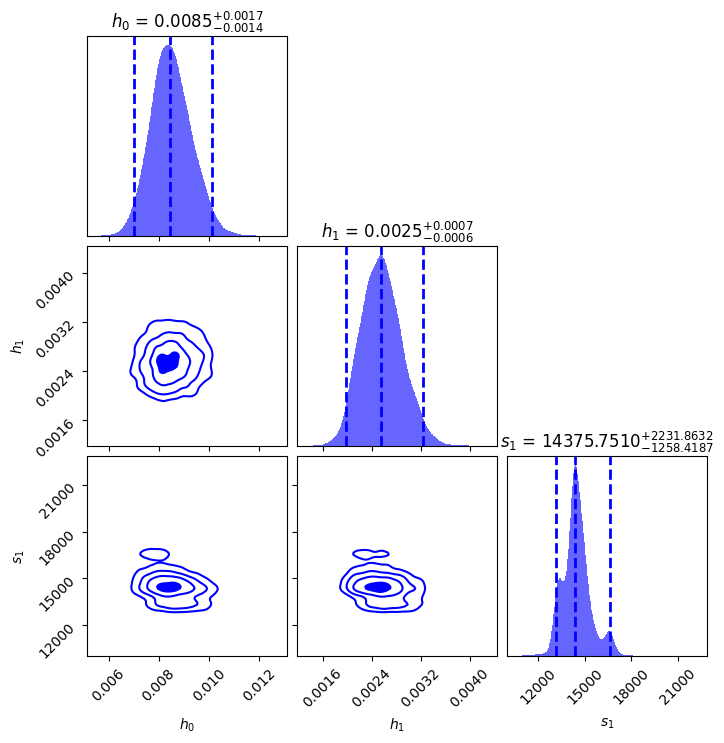

In [ ]:
from dynesty import plotting as dyplot

fig, axs = dyplot.runplot(results, lnz_error=True, logplot=True)
plt.savefig(os.path.join('figs','nested_sampling_runplot.png'), dpi=300)
fig, axs = dyplot.traceplot(results, labels=labels, trace_cmap="plasma", title_fmt=".4f", title_kwargs={"fontsize": 12})
plt.savefig(os.path.join('figs','nested_sampling_traceplot.png'), dpi=300)
fig, axs = dyplot.cornerplot(results, color="blue", labels=labels, show_titles=True, title_fmt=".4f", title_kwargs={"fontsize": 12})
plt.savefig(os.path.join('figs','nested_sampling_corner_plot.png'), dpi=300)

## Question 5: The $k$ change point models

### (a)

### (b)

(100001,)


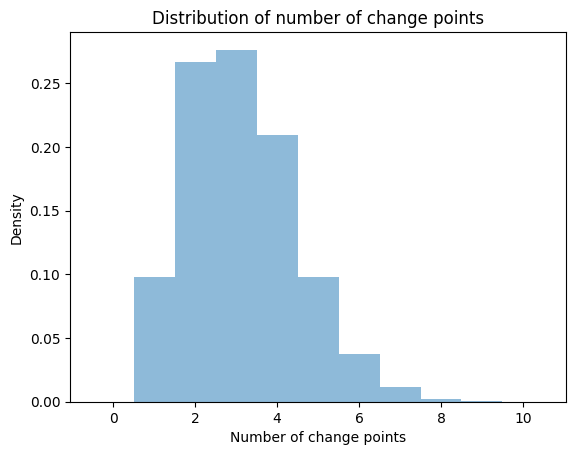

In [ ]:
# Load the MCMC chains
chains = rj_utils.load_chains('mcmc_chains.npy')
print(chains.shape)
k = rj_utils.extract_model_sizes(chains)

plt.hist(k, bins=np.arange(0, max(k)+1)-0.5, density=True, alpha=0.5)
plt.xlabel("Number of change points")
plt.ylabel("Density")
plt.title("Distribution of number of change points")
plt.show()

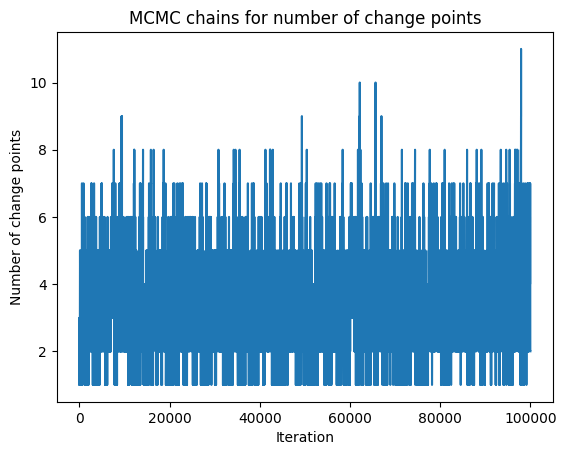

In [ ]:
# Plot the chains for k, the model size
iteration = np.arange(len(k))
plt.plot(iteration, k)
plt.xlabel("Iteration")
plt.ylabel("Number of change points")
plt.title("MCMC chains for number of change points")
plt.savefig(os.path.join('figs','mcmc_chains_rjmcmc_k.png'), dpi=300)
plt.show()

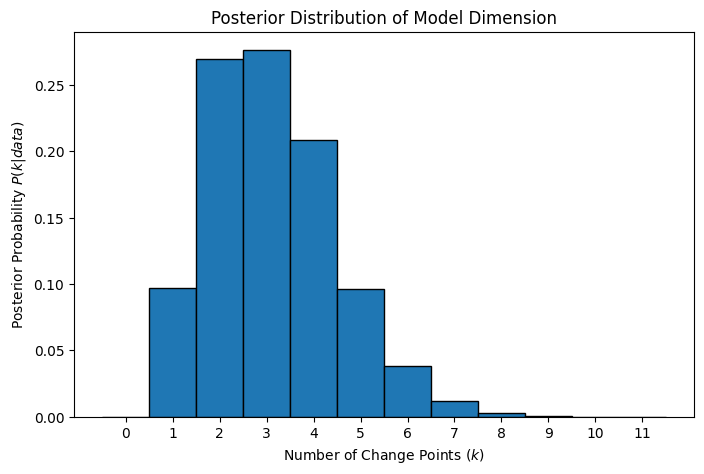

The preferred Maximum A Posteriori (MAP) number of change points is: 3


In [ ]:
# Discard the first 10% (10,000 steps) as burn-in
burn_in = 10000
post_burn_in_chain = rj_utils.post_burn_in_chain(chains, burn_in=burn_in)

# Extract the value of k for each state in the chain
k_samples = rj_utils.extract_model_sizes(post_burn_in_chain)

# Plot the posterior histogram
plt.figure(figsize=(8, 5))
bins = np.arange(-0.5, max(k_samples) + 1.5, 1)
plt.hist(k_samples, bins=bins, density=True, color='tab:blue', edgecolor='black')
plt.xlabel("Number of Change Points ($k$)")
plt.ylabel("Posterior Probability $P(k | data)$")
plt.title("Posterior distribution of model dimension")
plt.xticks(range(max(k_samples) + 1))
plt.savefig(os.path.join('figs','posterior_distribution_k.png'), dpi=300)
plt.show()

# Find the MAP
map_k = rj_utils.map_model_size(k_samples)
print(f"The preferred Maximum A Posteriori (MAP) number of change points is: {map_k}")

Evaluating rates across the chain (this might take a minute)...


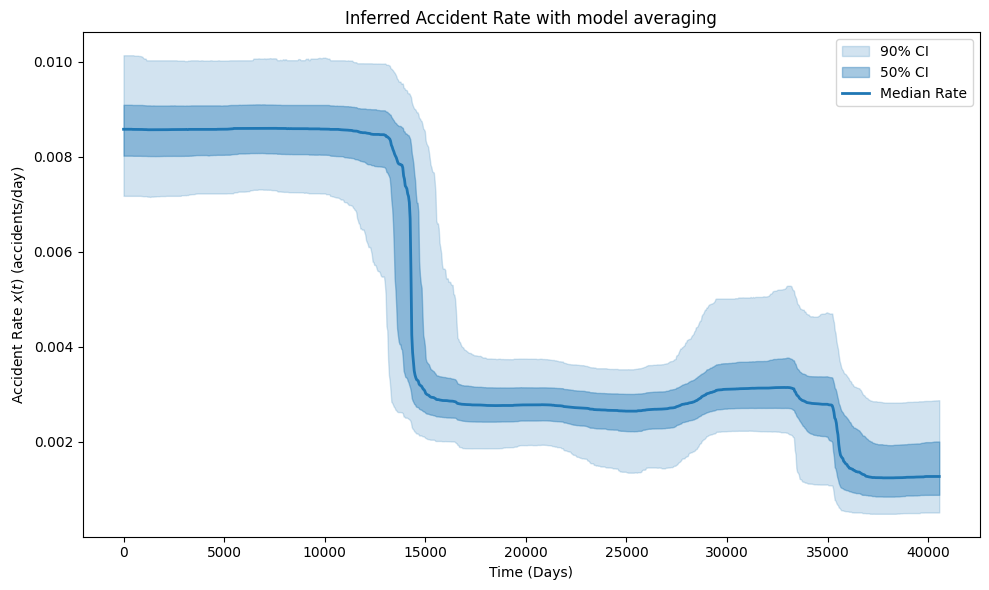

In [ ]:
# Create an array of times to evaluate the rate at (e.g., every 100 days)
t_eval, rate_evaluations = rj_utils.evaluate_rates_across_chain(
    post_burn_in_chain,
    total_period,
    n_eval=1000,
 )

# Calculate the percentiles for the uncertainty bands
rate_bands = rj_utils.summarize_rate_bands(rate_evaluations)
median_rate = rate_bands["median_rate"]
lower_90 = rate_bands["lower_90"]
upper_90 = rate_bands["upper_90"]
lower_50 = rate_bands["lower_50"]
upper_50 = rate_bands["upper_50"]

# Plotting
plt.figure(figsize=(10, 6))

# 90% credible interval (lighter shade)
plt.fill_between(t_eval, lower_90, upper_90, color='tab:blue', alpha=0.2, label='90% CI')

# 50% credible interval (darker shade)
plt.fill_between(t_eval, lower_50, upper_50, color='tab:blue', alpha=0.4, label='50% CI')

# Median rate
plt.plot(t_eval, median_rate, color='tab:blue', linewidth=2, label='Median Rate')

plt.xlabel("Time (Days)")
plt.ylabel("Accident Rate $x(t)$ (accidents/day)")
plt.title("Inferred Accident Rate with model averaging")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join('figs','inferred_accident_rate_model_averaging.png'), dpi=300)
plt.show()

## References

1. [emcee ReadTheDocs](https://emcee.readthedocs.io/en/stable/)
2. [Ensemble samplers with affine invariance (Goodman and Weare)](https://msp.org/camcos/2010/5-1/p04.xhtml)
3. [zeus ReadTheDocs](https://zeus-mcmc.readthedocs.io/en/latest/index.html)
4. [Ensemble slice samplers](https://arxiv.org/pdf/2002.06212)
5. [zeus paper](https://arxiv.org/pdf/2105.03468)